# 11.10.Adam算法

本章我们已经学习了许多有效优化的技术。在本节讨论之前，我们先详细回顾一下这些技术：

* 在[11.04_sgd](./11.04_sgd.ipynb)中，我们学习了：随机梯度下降在解决优化问题时比梯度下降更有效。
* 在[11.05_minibatch_sgd](./11.05_minibatch_sgd.ipynb)中，我们学习了：在一个小批量中使用更大的观测值集，可以通过向量化提供额外效率。这是高效的多机、多GPU和整体并行处理的关键。
* 在[11.06_momentum](./11.06_momentum.ipynb)中我们添加了一种机制，用于汇总过去梯度的历史以加速收敛。
* 在[11.07_adagrad](./11.07_adagrad.ipynb)中，我们通过对每个坐标缩放来实现高效计算的预处理器。
* 在[11.08_rmsprop](./11.08_rmsprop.ipynb)中，我们通过学习率的调整来分离每个坐标的缩放。

Adam算法 ([Kingma.Ba.2014](https://zh.d2l.ai/chapter_references/zreferences.html#id83))将所有这些技术汇总到一个高效的学习算法中。不出预料，作为深度学习中使用的更强大和有效的优化算法之一，它非常受欢迎。但是它并非没有问题，尤其是 ([Reddi.Kale.Kumar.2019](https://zh.d2l.ai/chapter_references/zreferences.html#id134))表明，有时Adam算法可能由于方差控制不良而发散。在完善工作中， ([Zaheer.Reddi.Sachan.ea.2018](https://zh.d2l.ai/chapter_references/zreferences.html#id193))给Adam算法提供了一个称为Yogi的热补丁来解决这些问题。下面我们了解一下Adam算法。

---

## 算法

Adam算法的关键组成部分之一是：它使用指数加权移动平均值来估算梯度的动量和二次矩，即它使用状态变量

$$\begin{aligned}
    \mathbf{v}_t & \leftarrow \beta_1 \mathbf{v}_{t-1} + (1 - \beta_1) \mathbf{g}_t, \\
    \mathbf{s}_t & \leftarrow \beta_2 \mathbf{s}_{t-1} + (1 - \beta_2) \mathbf{g}_t^2.
\end{aligned}\tag{11.10.1}$$

这里$\beta_1$和$\beta_2$是非负加权参数。常将它们设置为$\beta_1 = 0.9$和$\beta_2 = 0.999$。也就是说，方差估计的移动远远慢于动量估计的移动。注意，如果我们初始化$\mathbf{v}_0 = \mathbf{s}_0 = 0$，就会获得一个相当大的初始偏差。我们可以通过使用$\sum_{i=0}^t \beta^i = \frac{1 - \beta^t}{1 - \beta}$来解决这个问题。相应地，标准化状态变量由下式获得

$$\hat{\mathbf{v}}_t = \frac{\mathbf{v}_t}{1 - \beta_1^t} \text{ and } \hat{\mathbf{s}}_t = \frac{\mathbf{s}_t}{1 - \beta_2^t}.\tag{11.10.2}$$

有了正确的估计，我们现在可以写出更新方程。首先，我们以非常类似于RMSProp算法的方式重新缩放梯度以获得

$$\mathbf{g}_t' = \frac{\eta \hat{\mathbf{v}}_t}{\sqrt{\hat{\mathbf{s}}_t} + \epsilon}.\tag{11.10.3}$$

与RMSProp不同，我们的更新使用动量$\hat{\mathbf{v}}_t$而不是梯度本身。此外，由于使用$\frac{1}{\sqrt{\hat{\mathbf{s}}_t} + \epsilon}$而不是$\frac{1}{\sqrt{\hat{\mathbf{s}}_t + \epsilon}}$进行缩放，两者会略有差异。前者在实践中效果略好一些，因此与RMSProp算法有所区分。
通常，我们选择$\epsilon = 10^{-6}$，这是为了在数值稳定性和逼真度之间取得良好的平衡。

最后，我们简单更新：

$$\mathbf{x}_t \leftarrow \mathbf{x}_{t-1} - \mathbf{g}_t'.\tag{11.10.4}$$

回顾Adam算法，它的设计灵感很清楚：首先，动量和规模在状态变量中清晰可见，它们相当独特的定义使我们移除偏项（这可以通过稍微不同的初始化和更新条件来修正）。其次，RMSProp算法中两项的组合都非常简单。最后，明确的学习率$\eta$使我们能够控制步长来解决收敛问题。

---

## 环境准备

In [ ]:
import os
os.environ["TILE_FWK_DEVICE_ID"] = "0"

%matplotlib inline
import torch
from src.utils import *

<details class="original-text" style="border: 1px solid #e3e3ee; border-radius: 4px; margin: 20px 0; overflow: hidden;">
  <summary style="padding: 10px 14px; font-weight: 500; cursor: pointer; background-color: #f8f8fa; list-style: none; color: #374151; font-size: 14px; letter-spacing: 0.01em;">点击：查看/折叠原文</summary>
  <div class="original-content" style="padding: 14px; background-color: #ffffff; line-height: 1.65; color: #4b5563; font-size: 14px;">
    <pre style="background-color: transparent; color: #1f2937; border: 1px solid #e5e7eb; border-radius: 0; font-size: 13px; padding: 12px; margin: 0; font-family: Consolas, monospace;">%matplotlib inline
import torch
from d2l import torch as d2l</pre>
  </div>
</details>

---

## 实现

从头开始实现Adam算法并不难。为方便起见，我们将时间步$t$存储在`hyperparams`字典中。除此之外，一切都很简单。

In [7]:
def init_adam_states(feature_dim):
    v_w, v_b = torch.zeros((feature_dim, 1)), torch.zeros(1)
    s_w, s_b = torch.zeros((feature_dim, 1)), torch.zeros(1)
    return ((v_w, s_w), (v_b, s_b))

def adam(params, states, hyperparams):
    beta1, beta2, eps = 0.9, 0.999, 1e-6
    for p, (v, s) in zip(params, states):
        with torch.no_grad():
            v[:] = beta1 * v + (1 - beta1) * p.grad
            s[:] = beta2 * s + (1 - beta2) * torch.square(p.grad)
            v_bias_corr = v / (1 - beta1 ** hyperparams['t'])
            s_bias_corr = s / (1 - beta2 ** hyperparams['t'])
            p[:] -= hyperparams['lr'] * v_bias_corr / (torch.sqrt(s_bias_corr)
                                                       + eps)
        p.grad.data.zero_()
    hyperparams['t'] += 1

现在，我们用以上Adam算法来训练模型，这里我们使用$\eta = 0.01$的学习率。


loss: 0.243, 0.012 sec/epoch


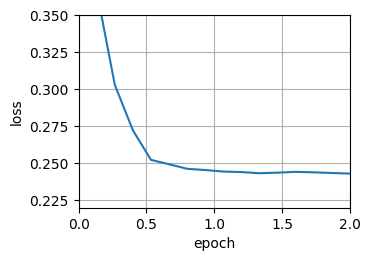

In [8]:
data_iter, feature_dim = get_data_ch11(batch_size=10)
train_ch11(adam, init_adam_states(feature_dim),
               {'lr': 0.01, 't': 1}, data_iter, feature_dim);

<details class="original-text" style="border: 1px solid #e3e3ee; border-radius: 4px; margin: 20px 0; overflow: hidden;">
  <summary style="padding: 10px 14px; font-weight: 500; cursor: pointer; background-color: #f8f8fa; list-style: none; color: #374151; font-size: 14px; letter-spacing: 0.01em;">点击：查看/折叠原文</summary>
  <div class="original-content" style="padding: 14px; background-color: #ffffff; line-height: 1.65; color: #4b5563; font-size: 14px;">
    <pre style="background-color: transparent; color: #1f2937; border: 1px solid #e5e7eb; border-radius: 0; font-size: 13px; padding: 12px; margin: 0 0 10px 0; font-family: Consolas, monospace;">data_iter, feature_dim = d2l.get_data_ch11(batch_size=10)
d2l.train_ch11(adam, init_adam_states(feature_dim),
               {'lr': 0.01, 't': 1}, data_iter, feature_dim);</pre><pre style="background-color: transparent; color: #1f2937; border-radius: 0; padding: 12px; font-family: Consolas, monospace; font-size: 13px; margin-top: 8px;">loss: 0.244, 0.015 sec/epoch</pre>
    <img src="./images/11.10.1.png" width="300">
  </div>
</details>

此外，我们可以用深度学习框架自带算法应用Adam算法，这里我们只需要传递配置参数。


loss: 0.244, 0.012 sec/epoch


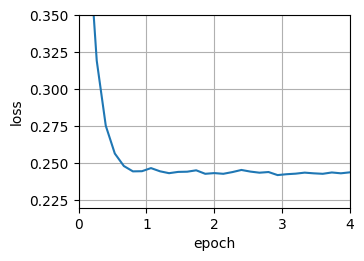

In [9]:
trainer = torch.optim.Adam
train_concise_ch11(trainer, {'lr': 0.01}, data_iter)

<details class="original-text" style="border: 1px solid #e3e3ee; border-radius: 4px; margin: 20px 0; overflow: hidden;">
  <summary style="padding: 10px 14px; font-weight: 500; cursor: pointer; background-color: #f8f8fa; list-style: none; color: #374151; font-size: 14px; letter-spacing: 0.01em;">点击：查看/折叠原文</summary>
  <div class="original-content" style="padding: 14px; background-color: #ffffff; line-height: 1.65; color: #4b5563; font-size: 14px;">
    <pre style="background-color: transparent; color: #1f2937; border: 1px solid #e5e7eb; border-radius: 0; font-size: 13px; padding: 12px; margin: 0 0 10px 0; font-family: Consolas, monospace;">trainer = torch.optim.Adam
d2l.train_concise_ch11(trainer, {'lr': 0.01}, data_iter)</pre><pre style="background-color: transparent; color: #1f2937; border-radius: 0; padding: 12px; font-family: Consolas, monospace; font-size: 13px; margin-top: 8px;">loss: 0.254, 0.015 sec/epoch</pre>
    <img src="./images/11.10.2.png" width="300">
  </div>
</details>

---

## Yogi

Adam算法也存在一些问题：即使在凸环境下，当$\mathbf{s}_t$的二次矩估计值爆炸时，它可能无法收敛。 ([Zaheer.Reddi.Sachan.ea.2018](https://zh.d2l.ai/chapter_references/zreferences.html#id193))为$\mathbf{s}_t$提出了的改进更新和参数初始化。论文中建议我们重写Adam算法更新如下：

$$\mathbf{s}_t \leftarrow \mathbf{s}_{t-1} + (1 - \beta_2) \left(\mathbf{g}_t^2 - \mathbf{s}_{t-1}\right).\tag{11.10.5}$$

每当$\mathbf{g}_t^2$具有值很大的变量或更新很稀疏时，$\mathbf{s}_t$可能会太快地“忘记”过去的值。一个有效的解决方法是将$\mathbf{g}_t^2 - \mathbf{s}_{t-1}$替换为$\mathbf{g}_t^2 \odot \mathop{\mathrm{sgn}}(\mathbf{g}_t^2 - \mathbf{s}_{t-1})$。这就是Yogi更新，现在更新的规模不再取决于偏差的量。

$$\mathbf{s}_t \leftarrow \mathbf{s}_{t-1} + (1 - \beta_2) \mathbf{g}_t^2 \odot \mathop{\mathrm{sgn}}(\mathbf{g}_t^2 - \mathbf{s}_{t-1}).\tag{11.10.6}$$

论文中，作者还进一步建议用更大的初始批量来初始化动量，而不仅仅是初始的逐点估计。

loss: 0.244, 0.012 sec/epoch


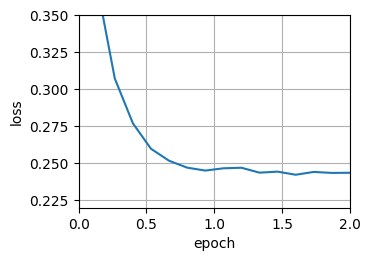

In [10]:
def yogi(params, states, hyperparams):
    beta1, beta2, eps = 0.9, 0.999, 1e-3
    for p, (v, s) in zip(params, states):
        with torch.no_grad():
            v[:] = beta1 * v + (1 - beta1) * p.grad
            s[:] = s + (1 - beta2) * torch.sign(
                torch.square(p.grad) - s) * torch.square(p.grad)
            v_bias_corr = v / (1 - beta1 ** hyperparams['t'])
            s_bias_corr = s / (1 - beta2 ** hyperparams['t'])
            p[:] -= hyperparams['lr'] * v_bias_corr / (torch.sqrt(s_bias_corr)
                                                       + eps)
        p.grad.data.zero_()
    hyperparams['t'] += 1

data_iter, feature_dim = get_data_ch11(batch_size=10)
train_ch11(yogi, init_adam_states(feature_dim),
               {'lr': 0.01, 't': 1}, data_iter, feature_dim);

<details class="original-text" style="border: 1px solid #e3e3ee; border-radius: 4px; margin: 20px 0; overflow: hidden;">
  <summary style="padding: 10px 14px; font-weight: 500; cursor: pointer; background-color: #f8f8fa; list-style: none; color: #374151; font-size: 14px; letter-spacing: 0.01em;">点击：查看/折叠原文</summary>
  <div class="original-content" style="padding: 14px; background-color: #ffffff; line-height: 1.65; color: #4b5563; font-size: 14px;">
    <pre style="background-color: transparent; color: #1f2937; border: 1px solid #e5e7eb; border-radius: 0; font-size: 13px; padding: 12px; margin: 0 0 10px 0; font-family: Consolas, monospace;">def yogi(params, states, hyperparams):
    beta1, beta2, eps = 0.9, 0.999, 1e-3
    for p, (v, s) in zip(params, states):
        with torch.no_grad():
            v[:] = beta1 * v + (1 - beta1) * p.grad
            s[:] = s + (1 - beta2) * torch.sign(
                torch.square(p.grad) - s) * torch.square(p.grad)
            v_bias_corr = v / (1 - beta1 ** hyperparams['t'])
            s_bias_corr = s / (1 - beta2 ** hyperparams['t'])
            p[:] -= hyperparams['lr'] * v_bias_corr / (torch.sqrt(s_bias_corr)
                                                       + eps)
        p.grad.data.zero_()
    hyperparams['t'] += 1

data_iter, feature_dim = d2l.get_data_ch11(batch_size=10)
d2l.train_ch11(yogi, init_adam_states(feature_dim),
               {'lr': 0.01, 't': 1}, data_iter, feature_dim);</pre><pre style="background-color: transparent; color: #1f2937; border-radius: 0; padding: 12px; font-family: Consolas, monospace; font-size: 13px; margin-top: 8px;">loss: 0.245, 0.015 sec/epoch</pre>
    <img src="./images/11.10.3.png" width="300">
  </div>
</details>

---

## 小结

* Adam算法将许多优化算法的功能结合到了相当强大的更新规则中。
* Adam算法在RMSProp算法基础上创建的，还在小批量的随机梯度上使用EWMA。
* 在估计动量和二次矩时，Adam算法使用偏差校正来调整缓慢的启动速度。
* 对于具有显著差异的梯度，我们可能会遇到收敛性问题。我们可以通过使用更大的小批量或者切换到改进的估计值$\mathbf{s}_t$来修正它们。Yogi提供了这样的替代方案。

---

## 练习

1. 调节学习率，观察并分析实验结果。
1. 试着重写动量和二次矩更新，从而使其不需要偏差校正。
1. 收敛时为什么需要降低学习率$\eta$？
1. 尝试构造一个使用Adam算法会发散而Yogi会收敛的例子。

详细参考答案见[11.10_adam](./answers/11.10_reference_answer.ipynb)


#### **参考答案**

In [ ]:
!cat ./answers/txt/11.10_reference.txt